<a href="https://colab.research.google.com/github/RahulMaheshwari12/coustmer-churn-prediction/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, PowerTransformer, MinMaxScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

### Importing Libraries
This cell imports all necessary libraries for data manipulation, visualization, preprocessing, model building, and evaluation.

In [116]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [117]:
df = pd.read_csv('/content/drive/MyDrive/rahul_data/train (3).csv')

In [118]:
df_test = pd.read_csv('/content/drive/MyDrive/rahul_data/test (2).csv')

### Data Loading
The training and testing datasets are loaded from CSV files into pandas DataFrames.

## Problem Statement: Customer Churn Prediction

This notebook aims to build a machine learning model to predict customer churn for a telecom company. Customer churn, also known as customer attrition, is a critical concern for businesses as retaining existing customers is often more cost-effective than acquiring new ones. By accurately identifying customers who are likely to churn, the company can proactively implement retention strategies.

### Objective:
Develop a predictive model that can identify customers at high risk of churning, based on various features such as customer demographics, services subscribed, contract details, and billing information. The model's performance will be evaluated using metrics relevant to imbalanced datasets, such as precision, recall, and F1-score, especially for the churn class (positive class).

In [119]:
def change_dtype(df, df_test):
  for col in df.columns:
    if df[col].dtype == 'float64':
      df[col] = df[col].astype('float32')
      df_test[col] = df_test[col].astype('float32')
    if df[col].dtype == 'int64':
      df[col] = df[col].astype('int32')
      df_test[col] = df_test[col].astype('int32')

  return df, df_test

### Helper Function for Data Type Conversion
This function `change_dtype` is designed to optimize memory usage by converting `float64` and `int64` columns to `float32` and `int32` respectively. This can be particularly useful for large datasets.

### Applying Data Type Conversion
The `change_dtype` function is applied to both the training and test DataFrames to reduce memory footprint and ensure consistent data types.

In [120]:
df

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


In [121]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [122]:
df.tail()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No
594193,594193,Female,1,Yes,No,2,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,54.55,108.05,Yes


### Data Inspection
These cells provide a quick overview of the dataset's structure, identify missing values, and display descriptive statistics for both object and numerical columns.

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [124]:
df  = df.dropna()

In [125]:
df =df.drop_duplicates()

In [126]:
df.describe(include= "object")

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


In [127]:
df.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [128]:
df = df.drop(["id", "gender"], axis= 1)
df_test = df_test.drop(["id", "gender"], axis= 1)

### Feature Engineering: Dropping Unnecessary Columns
The `id` column is dropped as it is merely an identifier and holds no predictive power. The `gender` column is also dropped, possibly to avoid potential bias or because it's deemed less relevant for this particular model after initial exploration.

In [129]:
cat_col = df.select_dtypes(include= "object")

for col in cat_col:
  if df[col].nunique() > 2:
    print(f"---{col}---")
    print(df[col].unique())
    print(f"number of unique values : {df[col].nunique()}")

---MultipleLines---
['No' 'Yes' 'No phone service']
number of unique values : 3
---InternetService---
['DSL' 'Fiber optic' 'No']
number of unique values : 3
---OnlineSecurity---
['Yes' 'No' 'No internet service']
number of unique values : 3
---OnlineBackup---
['No' 'Yes' 'No internet service']
number of unique values : 3
---DeviceProtection---
['Yes' 'No' 'No internet service']
number of unique values : 3
---TechSupport---
['Yes' 'No' 'No internet service']
number of unique values : 3
---StreamingTV---
['No' 'Yes' 'No internet service']
number of unique values : 3
---StreamingMovies---
['No' 'Yes' 'No internet service']
number of unique values : 3
---Contract---
['One year' 'Two year' 'Month-to-month']
number of unique values : 3
---PaymentMethod---
['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']
number of unique values : 4


### Exploring Categorical Features
This loop iterates through categorical columns (excluding 'Churn') to display unique values and their counts, helping to understand the distribution and variety within each category.

In [130]:
num_col = df.select_dtypes(exclude= "object").columns

for col in num_col:
    missing_spaces = df[df[col] == " "]
    print(f" In {col} columns, Rows with empty spaces: {len(missing_spaces)}")

 In SeniorCitizen columns, Rows with empty spaces: 0
 In tenure columns, Rows with empty spaces: 0
 In MonthlyCharges columns, Rows with empty spaces: 0
 In TotalCharges columns, Rows with empty spaces: 0


In [131]:
for col in num_col:
    missing_spaces = df[df[col] == 0.]
    print(f" In {col} columns, Rows with empty spaces: {len(missing_spaces)}")

 In SeniorCitizen columns, Rows with empty spaces: 526395
 In tenure columns, Rows with empty spaces: 0
 In MonthlyCharges columns, Rows with empty spaces: 0
 In TotalCharges columns, Rows with empty spaces: 0


### Checking for Missing Values/Anomalies in Numerical Columns
These cells check numerical columns for any entries that might be represented as empty strings (' ') or zero values, which could indicate missing data or data entry errors, especially in columns where zero might not be a meaningful value (like `TotalCharges` for new customers).

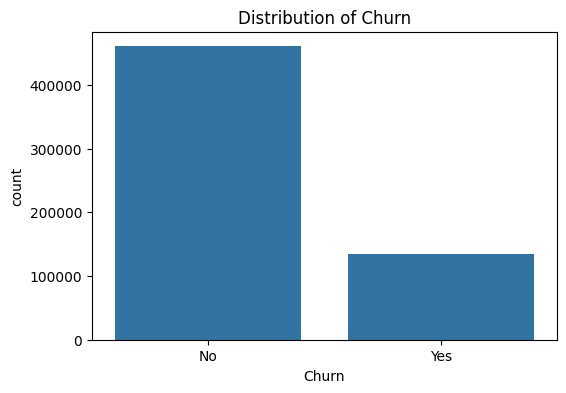

In [132]:
plt.figure(figsize= (6,4))
sns.countplot(x= "Churn", data= df)
plt.title("Distribution of Churn")
plt.show()

### Target Variable Distribution
This histogram visualizes the distribution of the target variable, 'Churn', providing insight into class imbalance.

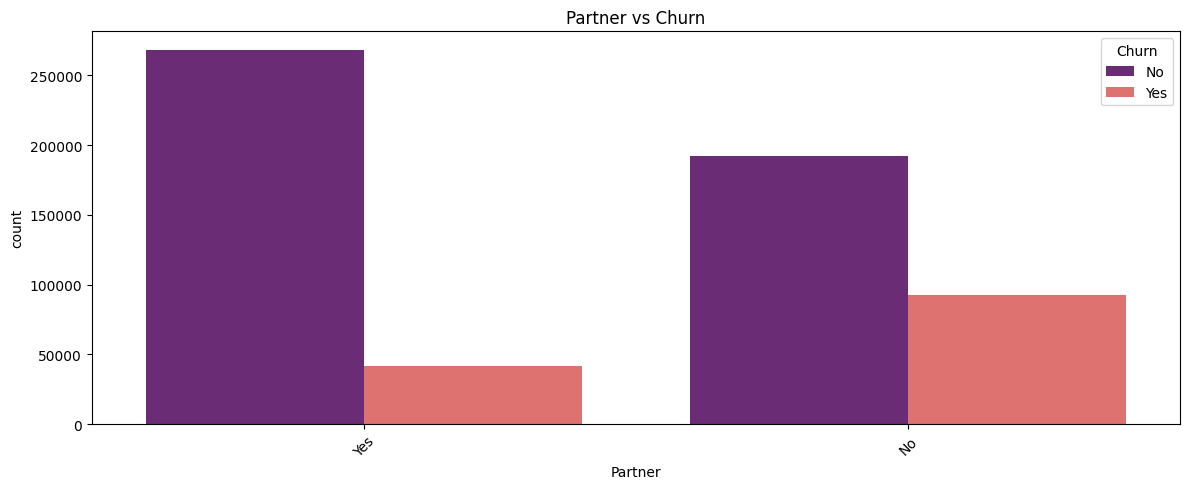

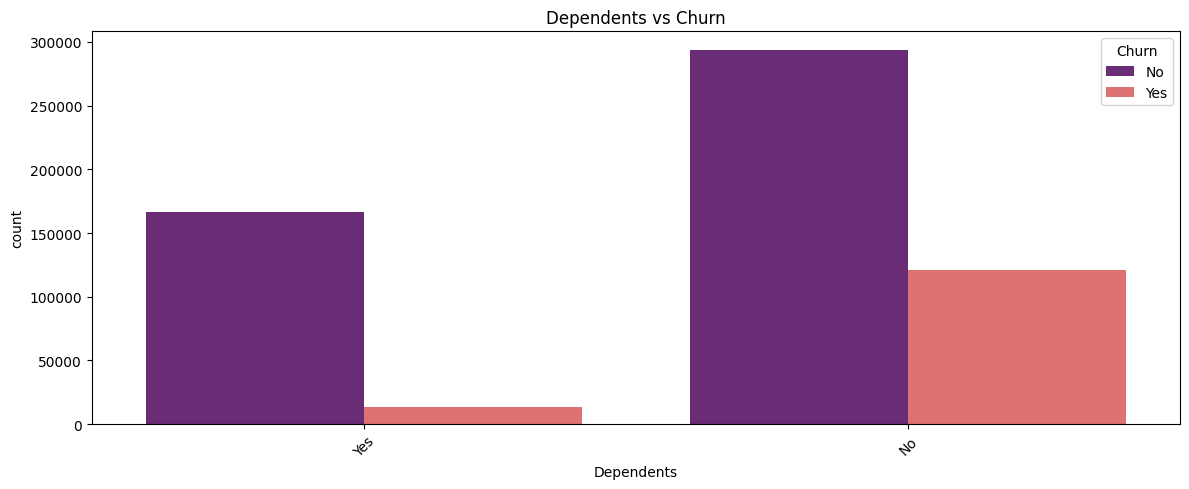

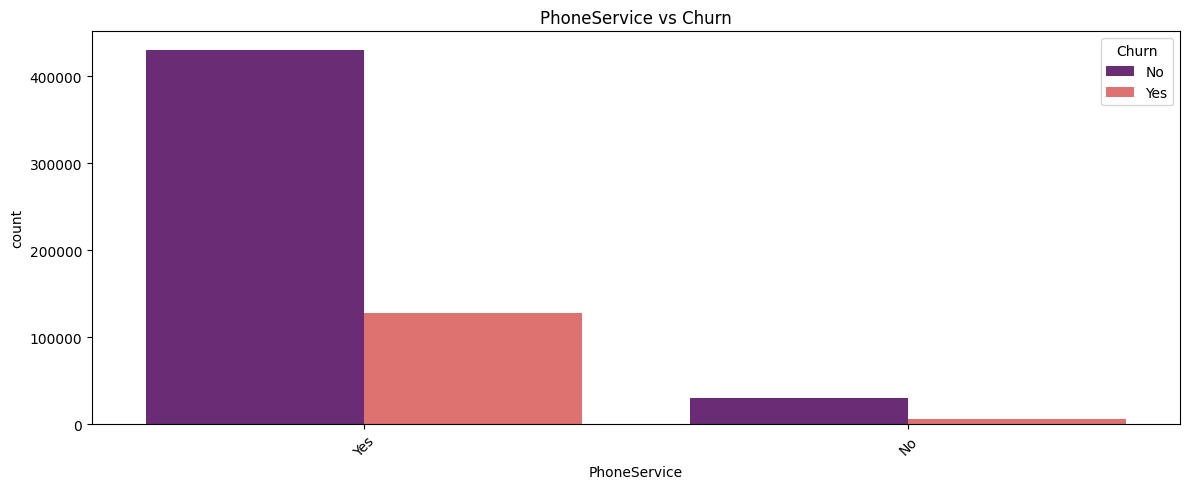

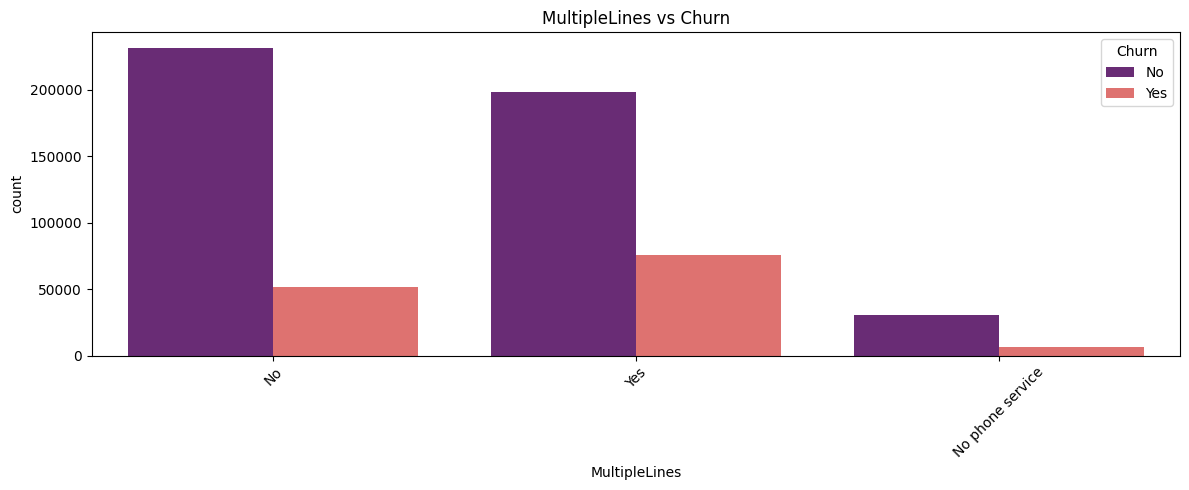

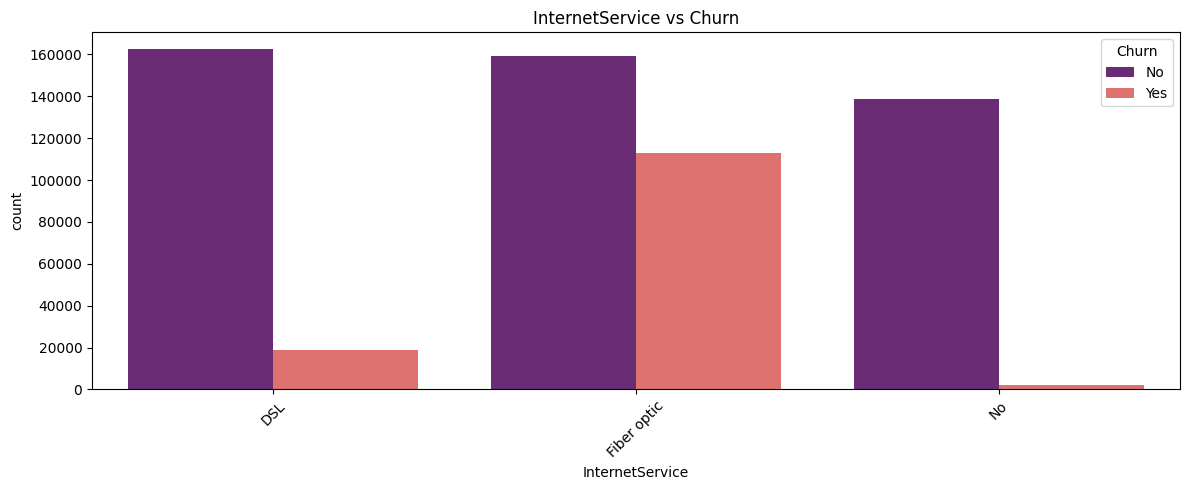

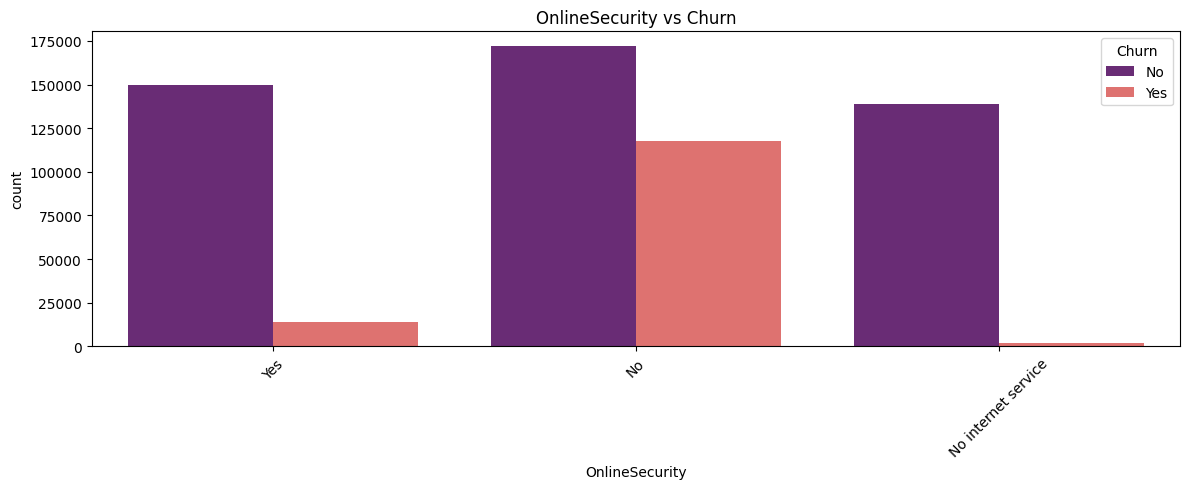

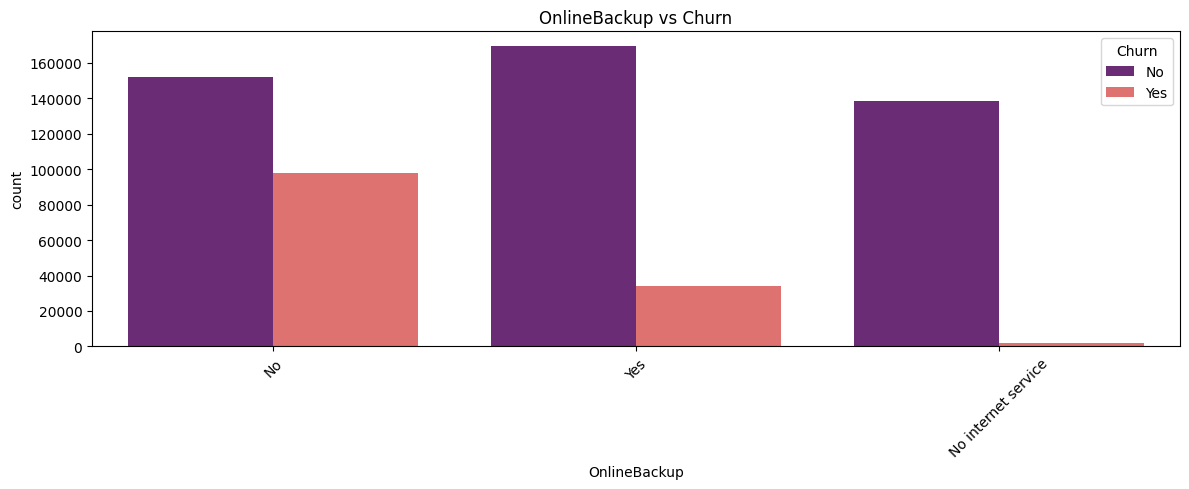

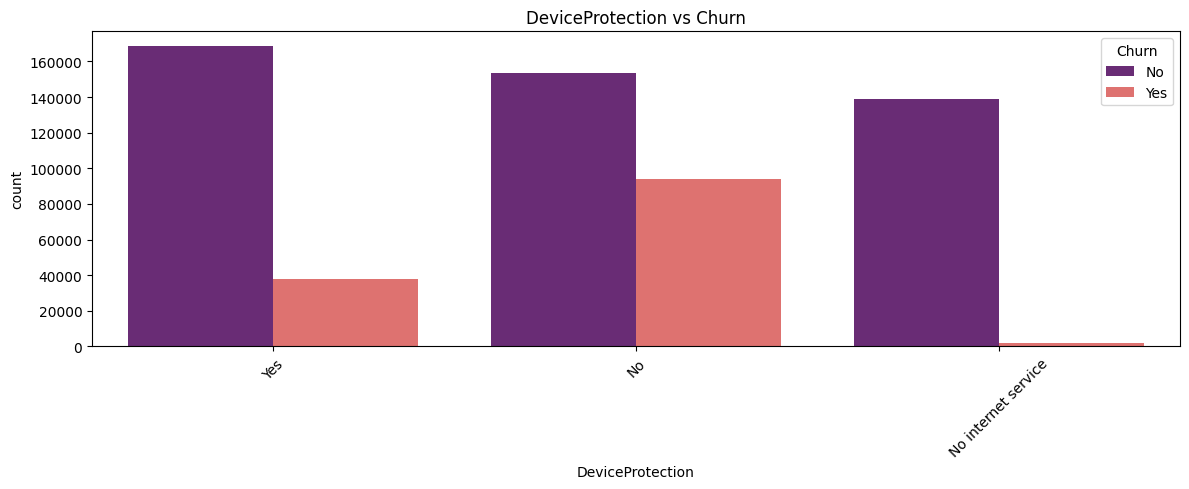

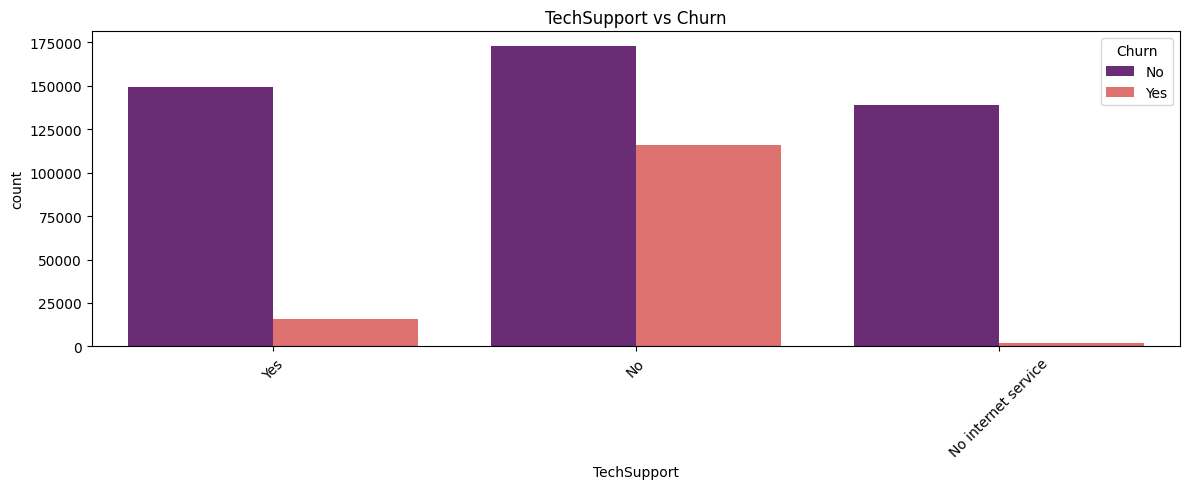

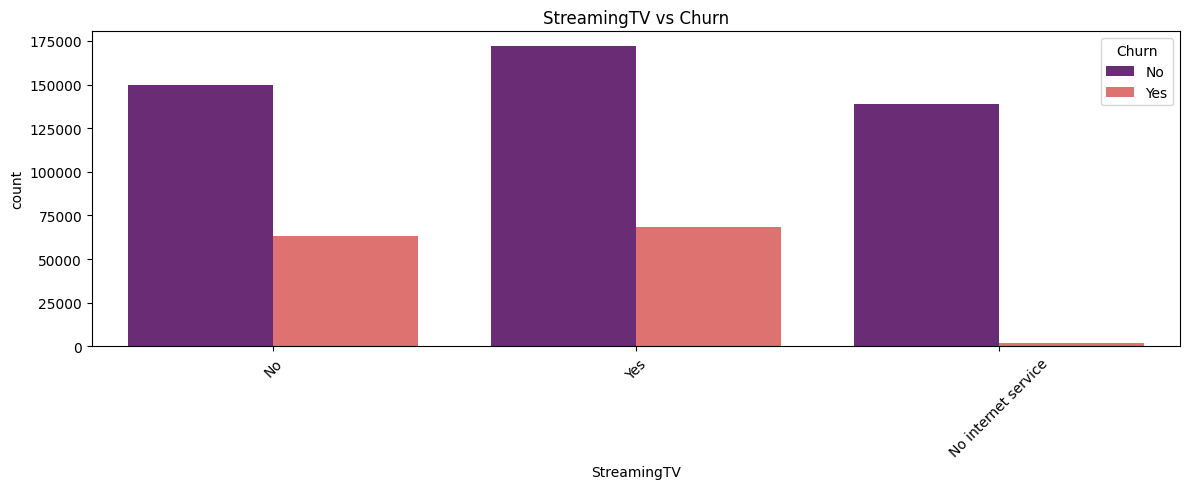

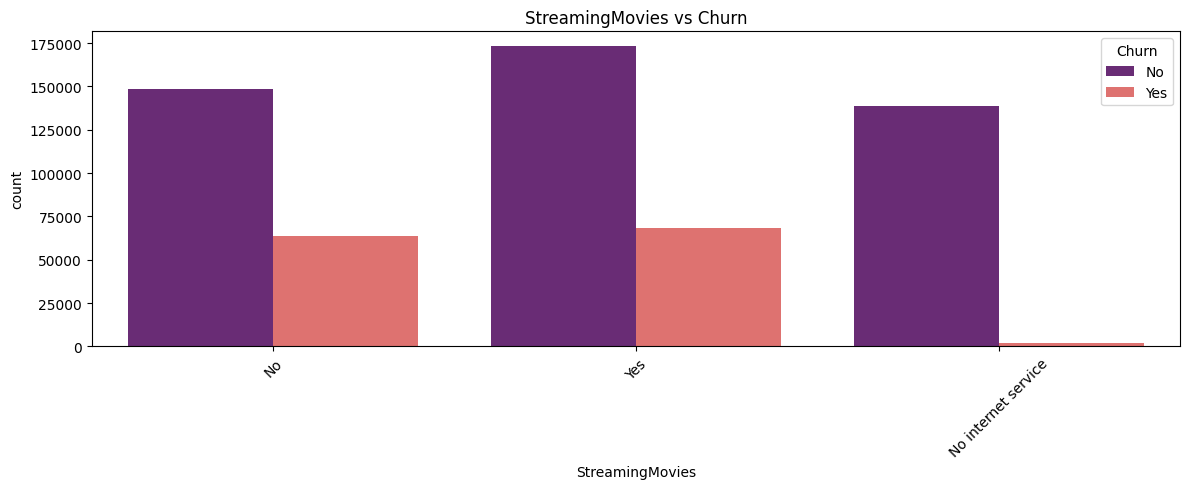

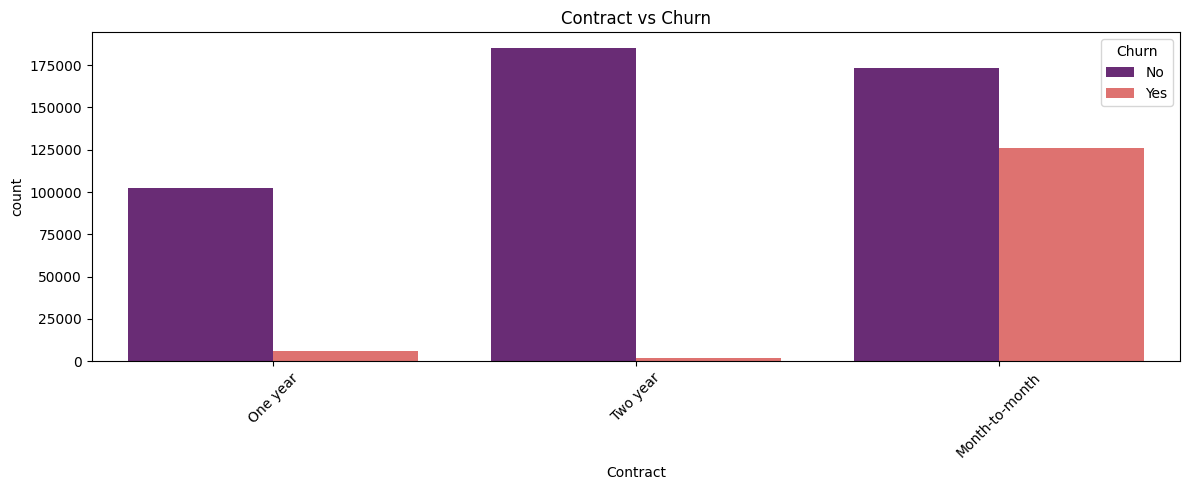

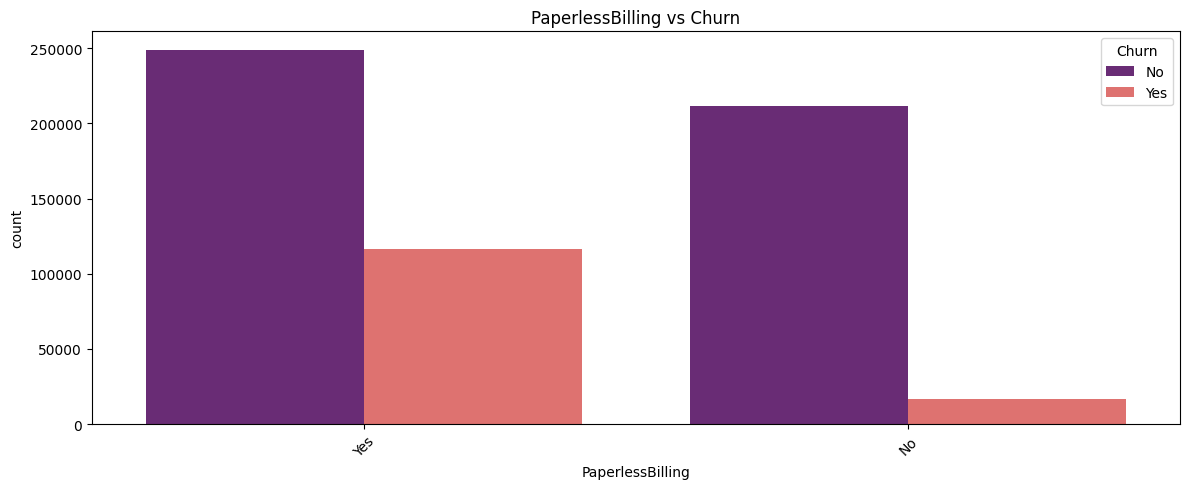

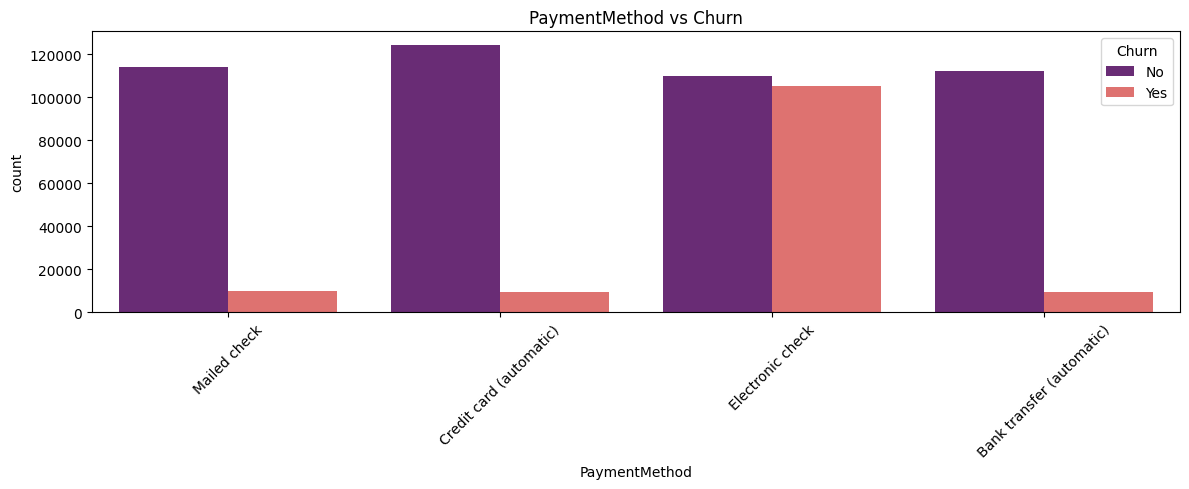

In [133]:
def plot_categorical_col(df, col, target= "Churn"):
    plt.figure(figsize= (12, 5))

    sns.countplot(x= col, data= df, hue= target, palette= "magma")
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation= 45)

    plt.tight_layout()
    plt.show()
    plt.close()

cat_col = df.select_dtypes(include= "object").columns.drop("Churn")

for col in cat_col:
    plot_categorical_col(df, col)

### Helper Function for Categorical Feature Visualization
This function `plot_categorical_col` is defined to generate count plots for categorical features, showing the distribution of each category with respect to the 'Churn' target. This helps in understanding the relationship between categorical features and customer churn.

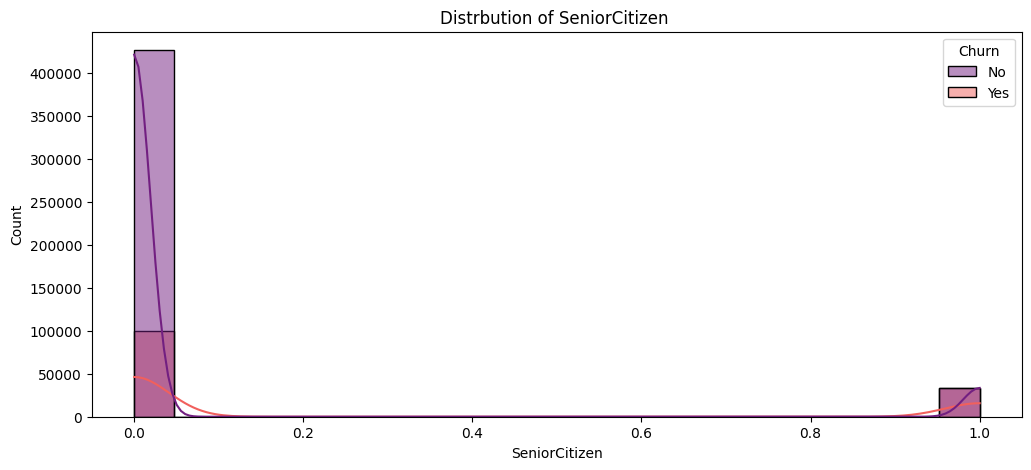

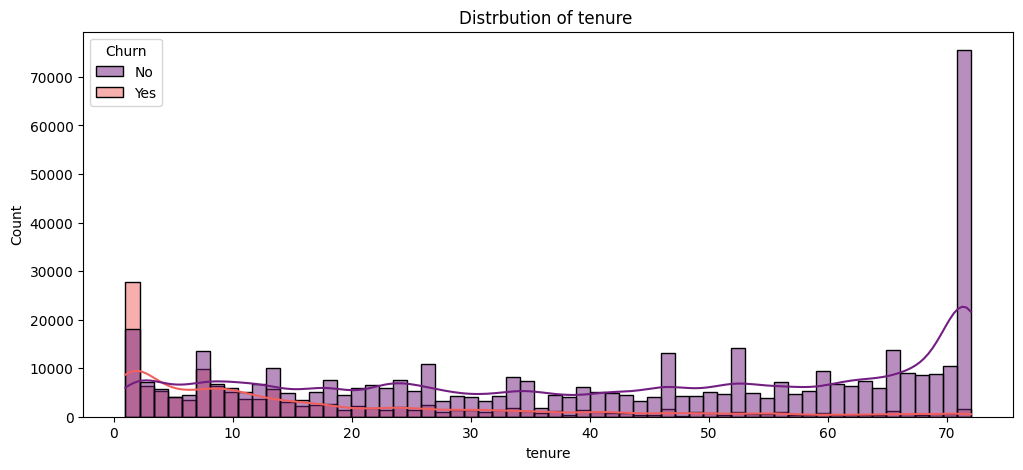

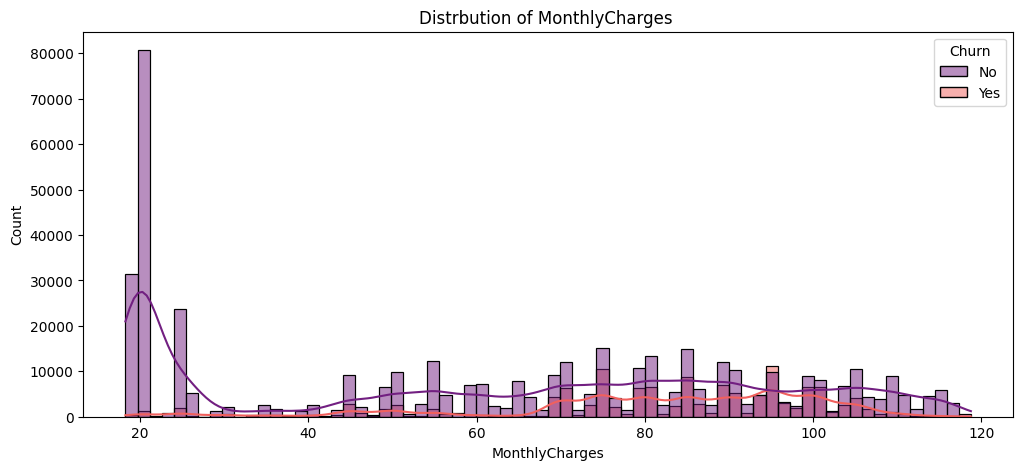

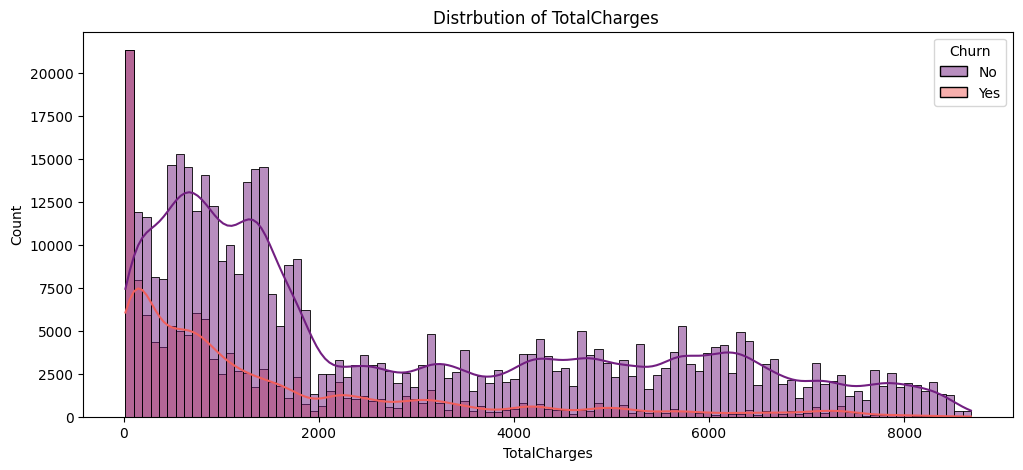

In [134]:
for col in num_col:
    plt.figure(figsize=(12, 5))
    sns.histplot(data= df, x= col, hue= "Churn", palette= "magma", kde= True)
    plt.title(f"Distrbution of {col} ")
    plt.show()

### Numerical Feature Distributions
These cells generate histograms for numerical columns, showing their distribution and how they relate to churn. KDE (Kernel Density Estimate) is used to smooth the distributions.

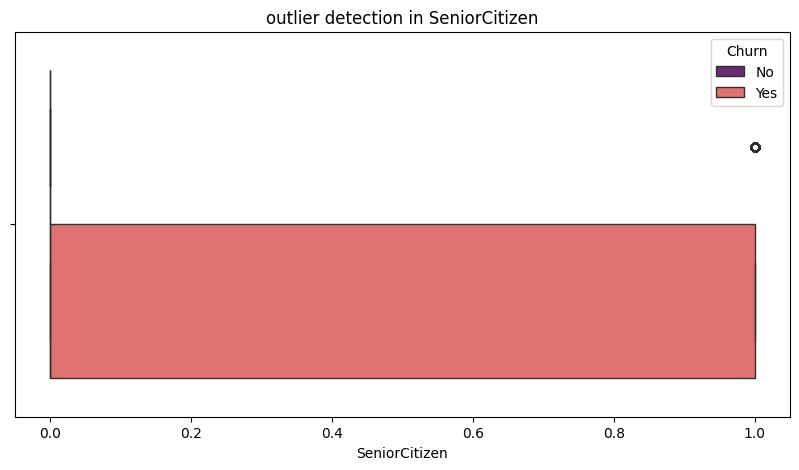

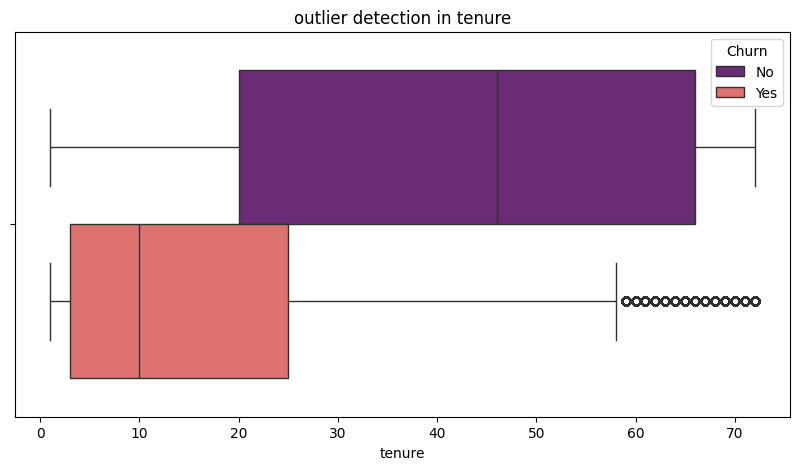

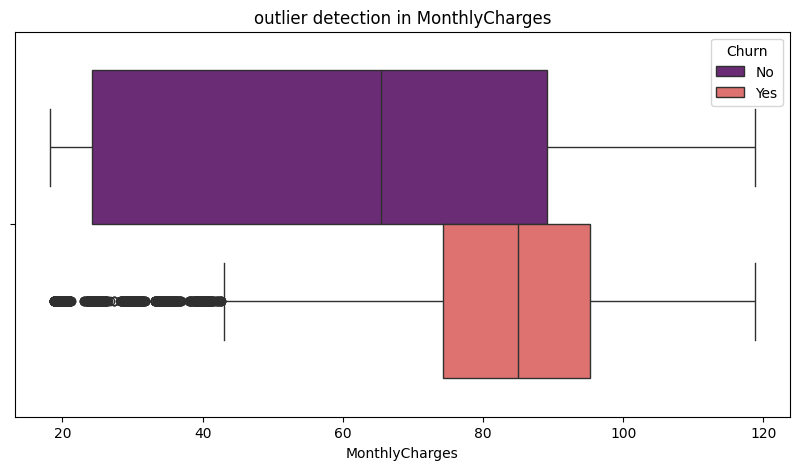

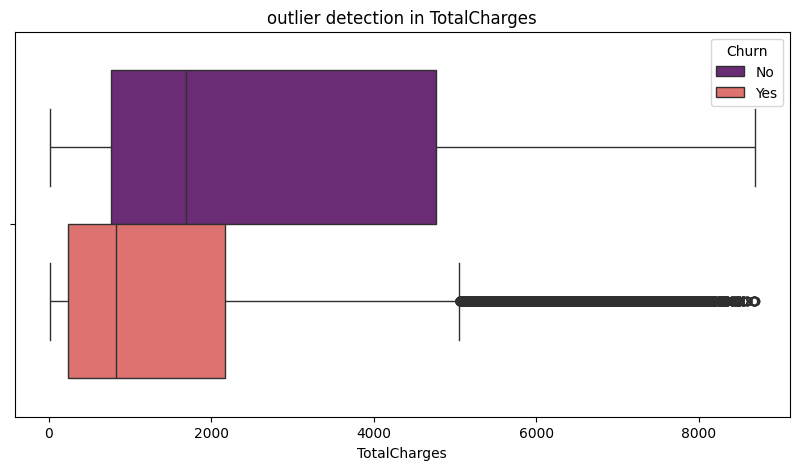

In [135]:
for col in num_col:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data= df, x= col,hue= "Churn", palette= "magma")
    plt.title(f"outlier detection in {col}")
    plt.show()

### Outlier Detection in Numerical Features
Box plots are used to visualize the distribution of numerical features and identify potential outliers, colored by the 'Churn' status to see if outliers are more prevalent in one class.

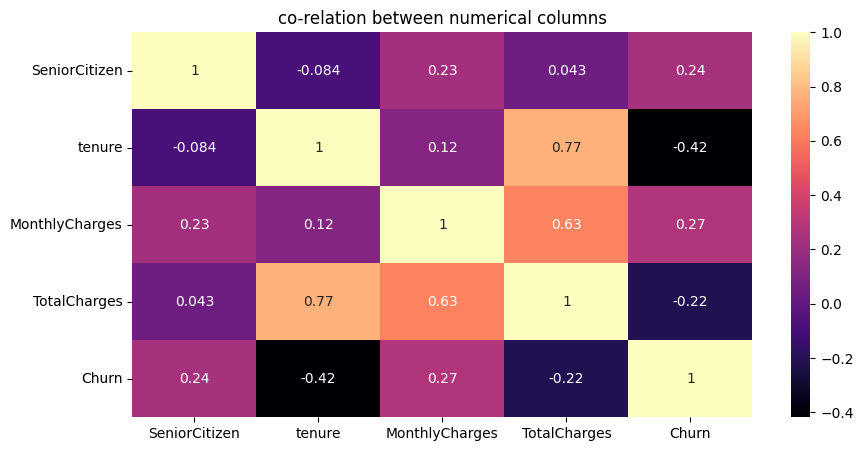

In [136]:
corr_df = df[num_col].copy()
corr_df["Churn"] = df["Churn"].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(10,5))
sns.heatmap(corr_df.corr(), annot= True, cmap= "magma")
plt.title("co-relation between numerical columns")
plt.show()

### Correlation Analysis of Numerical Features
A heatmap visualizes the correlation matrix of numerical features with the 'Churn' target. This helps identify which numerical features have a stronger linear relationship with churn.

In [137]:
df

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


### Encoding Target Variable
In this step, the categorical 'Churn' column is converted into a numerical format, where 'Yes' is mapped to 1 and 'No' to 0. This is a necessary step for machine learning models that require numerical inputs.

In [138]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [139]:
X = df.drop('Churn', axis= 1)
y = df['Churn']

### Splitting Features and Target Variable
The dataset is divided into features (`X`) and the target variable (`y`), which is 'Churn'. This separation is crucial for preparing data for model training.

In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Data Splitting: Training and Testing Sets
The dataset is split into training and testing sets using `train_test_split`. This allows the model to be trained on one portion of the data and evaluated on unseen data to assess its generalization capability.

In [141]:
oridnal_encoder = OrdinalEncoder()

In [142]:
onehotencoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
onehotencoder

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

### Initializing Encoders
`OrdinalEncoder` and `OneHotEncoder` are initialized. `OrdinalEncoder` is typically used for categorical features with an inherent order, while `OneHotEncoder` is used for nominal categorical features to avoid implying order and prevent models from making incorrect assumptions.

In [143]:
cat_col = df.select_dtypes(include= "object").columns

def encoding_data(X_train, X_test, cat_cols):
    binary_cols = [col for col in cat_cols if X_train[col].nunique() == 2]
    multi_cols = [col for col in cat_cols if X_train[col].nunique() > 2]

    preprocessor = ColumnTransformer(
        transformers=[
            ('bin', oridnal_encoder, binary_cols),
            ('multi', onehotencoder, multi_cols)
        ],remainder='passthrough')

    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)
    df_test_encoded = preprocessor.transform(df_test)

    new_cols = binary_cols + list(preprocessor.named_transformers_['multi'].get_feature_names_out(multi_cols))

    other_cols = [c for c in X_train.columns if c not in binary_cols + multi_cols]
    all_final_cols = new_cols + other_cols

    X_train_final = pd.DataFrame(X_train_encoded, columns=all_final_cols, index=X_train.index)
    X_test_final = pd.DataFrame(X_test_encoded, columns=all_final_cols, index=X_test.index)
    df_test_final = pd.DataFrame(df_test_encoded, columns= all_final_cols, index=df_test.index)

    return X_train_final, X_test_final, preprocessor, all_final_cols, df_test_final

### Helper Function for Categorical Feature Encoding
The `encoding_data` function encapsulates the process of applying both ordinal and one-hot encoding to categorical columns. It distinguishes between binary and multi-category columns, ensuring appropriate encoding methods are used.

In [144]:
X_train, X_test, preprocessor_enoding, all_final_col, df_test = encoding_data(X_train, X_test, cat_col)

### Applying Categorical Feature Encoding
The `encoding_data` function is called to transform the categorical features in the training, testing, and original `df_test` datasets. This converts all categorical variables into a numerical format suitable for machine learning algorithms.

In [145]:
X_train

,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,...,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
107052,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,67.0,83.00,5293.40
249213,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,47.0,19.50,929.30
206374,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,65.0,100.20,6844.50
347184,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,51.0,101.15,5264.50
99430,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,59.0,81.30,4859.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,72.0,25.55,1872.20
259178,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,66.0,67.80,4758.80
365838,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,27.0,20.20,546.40
131932,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,62.0,68.60,4059.35


In [146]:
X_test

,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,...,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
392211,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,71.0,89.45,6293.45
370260,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,44.0,75.55,3888.60
65386,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,53.0,19.75,1077.75
526552,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,52.0,55.20,2719.20
3996,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,44.70,44.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204582,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,20.15,147.75
501,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,41.0,82.00,3090.65
251137,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,57.0,95.40,5538.45
48585,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,13.0,70.50,923.85


### Initializing StandardScaler
`StandardScaler` is initialized. This transformer standardizes features by removing the mean and scaling to unit variance, which is often beneficial for models sensitive to feature scales like Logistic Regression.

In [147]:
scaler = StandardScaler()
scaler

StandardScaler()

### Helper Function for Numerical Feature Scaling
The `scaling_data` function applies different scaling techniques based on the distribution characteristics of numerical columns:
- `MonthlyCharges` is scaled using `StandardScaler`.
- `TotalCharges` is transformed using `PowerTransformer` to handle skewness.
- `tenure` is scaled using `MinMaxScaler` to normalize its range.

In [148]:
def scaling_data(X_train, X_test, df_test):
    preprocessor = ColumnTransformer(
        transformers = [
            ('normal_col', StandardScaler(), ['MonthlyCharges']),
            ('ri_skewed', PowerTransformer(), ['TotalCharges']),
            ('bimodal', MinMaxScaler(), ['tenure'])
    ], remainder='passthrough')

    X_train_scaled = preprocessor.fit_transform(X_train)
    X_test_scaled = preprocessor.transform(X_test)
    df_test_scaled = preprocessor.transform(df_test)

    all_columns = (['MonthlyCharges', 'TotalCharges', 'tenure'] + [cols for cols in X_train.columns if cols not in ['MonthlyCharges', 'TotalCharges', 'tenure']])

    return pd.DataFrame(X_train_scaled, columns= all_columns), pd.DataFrame(X_test_scaled, columns= all_columns), preprocessor, pd.DataFrame(df_test_scaled, columns= all_columns)


### Applying Numerical Feature Scaling
The `scaling_data` function is applied to the training, testing, and `df_test` datasets. This ensures that numerical features are appropriately scaled and transformed, which can improve model performance and convergence.

In [149]:
X_train, X_test, fitted_scaler_preprocessor, df_test = scaling_data(X_train, X_test, df_test)

In [150]:
X_train

,MonthlyCharges,TotalCharges,tenure,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen
0,0.550989,1.152315,0.929577,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-1.493158,-0.434657,0.647887,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,1.104680,1.453703,0.901408,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.135261,1.146111,0.704225,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.496264,1.056396,0.816901,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475350,-1.298401,0.119485,1.000000,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
475351,0.061681,1.033234,0.915493,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
475352,-1.470624,-0.792317,0.366197,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
475353,0.087434,0.861447,0.859155,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [151]:
X_test

,MonthlyCharges,TotalCharges,tenure,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen
0,0.758623,1.353042,0.985915,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.311164,0.816215,0.605634,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-1.485110,-0.325691,0.732394,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-0.343929,0.458695,0.718310,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.681938,-1.943295,0.000000,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118834,-1.472234,-1.487566,0.112676,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
118835,0.518798,0.582866,0.563380,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
118836,0.950161,1.203938,0.788732,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118837,0.148598,-0.438896,0.169014,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### Helper Function for Model Training and Evaluation
This `train_model` function simplifies the process of training a given model, making predictions, and evaluating its performance using a classification report. It also captures predicted probabilities if the model supports it.

In [152]:
def train_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = None

    print(f"--- Base model: {type(model).__name__} ---")
    print(classification_report(y_test, y_pred))
    return model, y_pred, y_probs

### Training Initial Logistic Regression Model
A Logistic Regression model is trained with `class_weight='balanced'` to address potential class imbalance in the target variable. The `train_model` function is used to fit the model and display an initial classification report.

In [153]:
logistic_model = train_model(LogisticRegression(class_weight= 'balanced'), X_train, X_test, y_train, y_test)

--- Base model: LogisticRegression ---
              precision    recall  f1-score   support

           0       0.96      0.79      0.87     91935
           1       0.55      0.88      0.68     26904

    accuracy                           0.81    118839
   macro avg       0.75      0.83      0.77    118839
weighted avg       0.86      0.81      0.82    118839



### Helper Function for Hyperparameter Tuning
The `hyper_model_training` function performs randomized search cross-validation to find the best hyperparameters for a given model. It uses `StratifiedKFold` for robust evaluation, especially for imbalanced datasets, and `f1` scoring to optimize for a balance between precision and recall.

In [154]:
def hyper_model_training(model, param_grid, X_train, X_test, y_train, y_test):
    skf = StratifiedKFold(n_splits= 3, shuffle= True, random_state= 42)
    rando_search = RandomizedSearchCV(estimator= model, param_distributions= param_grid, cv= skf, scoring= 'f1', n_jobs= 2, random_state= 42, n_iter= 15, verbose= 1)

    rando_search.fit(X_train, y_train)
    best_model = rando_search.best_estimator_
    print(f"Best parameter: {rando_search.best_params_}")

    return train_model(best_model, X_train, X_test, y_train, y_test)

### Hyperparameter Tuning for Logistic Regression

### Defining Hyperparameter Grid
This cell defines the `lr_params` dictionary, which specifies the hyperparameter search space for the Logistic Regression model. It includes parameters like `C` (regularization strength), `class_weight`, `solver`, `penalty`, and `max_iter`.

In [155]:
lr_params = {
    'C': np.logspace(-4, 4, 15),
    'class_weight': ['balanced'],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
    'max_iter': [1000, 2000]
}

best_lr_model, y_pred_lr, y_probs_lr = hyper_model_training(LogisticRegression(random_state=42), lr_params, X_train, X_test, y_train, y_test)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameter: {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 1000, 'class_weight': 'balanced', 'C': np.float64(0.005179474679231213)}
--- Base model: LogisticRegression ---
              precision    recall  f1-score   support

           0       0.96      0.79      0.87     91935
           1       0.55      0.87      0.68     26904

    accuracy                           0.81    118839
   macro avg       0.75      0.83      0.77    118839
weighted avg       0.86      0.81      0.82    118839



### Evaluating Thresholds for Optimal Performance
This loop iterates through different probability thresholds (0.5, 0.6, 0.7, 0.8) to determine the impact on the classification report. This helps in finding an optimal threshold that balances precision and recall for the 'Churn' class, which is crucial in imbalanced datasets.

In [156]:
for i in [0.5, 0.6, 0.7, 0.8]:
    preds = (y_probs_lr >= i).astype(int)
    print(f"\nThreshold = {i}")
    print(classification_report(y_test, preds))


Threshold = 0.5
              precision    recall  f1-score   support

           0       0.96      0.79      0.87     91935
           1       0.55      0.87      0.68     26904

    accuracy                           0.81    118839
   macro avg       0.75      0.83      0.77    118839
weighted avg       0.86      0.81      0.82    118839


Threshold = 0.6
              precision    recall  f1-score   support

           0       0.94      0.84      0.89     91935
           1       0.60      0.83      0.69     26904

    accuracy                           0.83    118839
   macro avg       0.77      0.83      0.79    118839
weighted avg       0.86      0.83      0.84    118839


Threshold = 0.7
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     91935
           1       0.65      0.74      0.69     26904

    accuracy                           0.85    118839
   macro avg       0.78      0.81      0.80    118839
weighted avg       0.86

### Applying Optimal Threshold for Final Prediction
Based on the threshold evaluation, an optimal threshold (0.6 in this case) is chosen to convert predicted probabilities into binary class labels. The final classification report using this threshold is then displayed.

In [157]:
# applying best optimal thresshold for prediciton
threshold = 0.6
preds_06 = (y_probs_lr >= threshold).astype(int)

print(f"Final Model Report (Threshold = {threshold})")
print(classification_report(y_test, preds_06))

Final Model Report (Threshold = 0.6)
              precision    recall  f1-score   support

           0       0.94      0.84      0.89     91935
           1       0.60      0.83      0.69     26904

    accuracy                           0.83    118839
   macro avg       0.77      0.83      0.79    118839
weighted avg       0.86      0.83      0.84    118839



### Generating Predictions on Test Data
The best Logistic Regression model is used to predict churn probabilities on the unseen `df_test` dataset. These probabilities are then converted into binary predictions using the previously determined optimal threshold of 0.6.

In [158]:
df_test_probs = best_lr_model.predict_proba(df_test)[:, 1]
df_test_predictions = (df_test_probs >= 0.6).astype(int)

print("First 10 predictions on the test data:")
print(df_test_predictions[:10])

First 10 predictions on the test data:
[0 0 0 0 1 0 1 0 0 1]


### Saving the Trained Model
The best performing Logistic Regression model, `best_lr_model`, is saved to a file named 'best_lr_model.pkl' using `joblib`. This allows the model to be loaded and reused later without retraining.

In [159]:
import joblib
joblib.dump(best_lr_model, "best_lr_model.pkl")

['best_lr_model.pkl']

### Verifying Saved Model
This command lists the files in the current directory, allowing you to confirm that `best_lr_model.pkl` has been successfully saved.

You can find the saved model `best_lr_model.pkl` in the current working directory. Use the following code to list the files and download it if needed.

In [160]:
# List files in the current directory to verify the saved model
!ls -F


best_lr_model.pkl  drive/  sample_data/


### Downloading the Saved Model
This cell provides functionality to download the 'best_lr_model.pkl' file from the Colab environment to your local machine, enabling its use outside of this notebook.

In [161]:
# Download the saved model
from google.colab import files
files.download('best_lr_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>